# Part 1: PCA and LDA on a single tree

This notebook contains a single tree, timing_MC_nue_may07_2.root, which I looked at in May/early June. 
The data in this file has clearly been very pre-processed as we achieved somewhat clean separation in LDA using just INNO as labels, and for "random" variables we found to give nice separation after trial and error.
You should view this file as our attempt to understand the data before starting a more serious analysis a few days later.

In [1]:
%load_ext autoreload
%autoreload 2
from utils import *

file = uproot.open(r"C:\Users\Mathias\Desktop\NEUTRINO CODING\timing_MC_nue_may07_2.root")
tree = file["TTiming"]

## Understanding the data 

In [2]:
#this is how long the IPFS (identity of outgoing particles) array is (5675)
print(f"length identityOfOutgoingParticles array: {len(tree['MCEVNT.IPFS'].array())}")

#NFSP is supposed to say how many outgoing particles exist
numberOfOutgoingParticlesArray = tree["MCEVNT.NFSP"].array()

print(f"as we can see the length of numberOfOutgoingParticles is also: {len(numberOfOutgoingParticlesArray)}")
print(f"and particle # for each event are clearly > 1: {numberOfOutgoingParticlesArray} \n")



print(f"yet each identityOfOutgoingParticle entry contains only contains one number (looks like exclusively e+, e-, neutrino): {tree['MCEVNT.IPFS'].array()} \n")

someEvent = random.randint(1,5675)

#so then lets check some random entry in this 5675 entry long IPFS array
identitiesRandomEvent = tree["MCEVNT.IPFS"].array()[someEvent]
numberOfParticlesRandomEvent = tree["MCEVNT.NFSP"].array()[someEvent]

print(f"theres also something called NDCY that gives 'number of decay particles' instead of 'number of final state particles': {tree['MCEVNT.NDCY'].array()} ")
print(f"and this array is also of length: {len(tree['MCEVNT.NDCY'].array())} \n")

print(f"if we check some random event (1,5675), \n numberOfOutgoingParticles = {numberOfParticlesRandomEvent} \n identitiesOfOutgoingParticles = {identitiesRandomEvent}")

print(f"also the data type of the identitiesRandomEvent is {type(identitiesRandomEvent)}")

length identityOfOutgoingParticles array: 5675
as we can see the length of numberOfOutgoingParticles is also: 5675
and particle # for each event are clearly > 1: [3, 5, 4, 7, 7, 2, 4, 5, 3, 9, 5, 5, ..., 3, 3, 6, 5, 2, 3, 5, 10, 9, 6, 2, 2] 

yet each identityOfOutgoingParticle entry contains only contains one number (looks like exclusively e+, e-, neutrino): [[3], [2], [3], [4], [4], [3], [4], [3], ..., [3], [4], [4], [4], [4], [3], [3]] 

theres also something called NDCY that gives 'number of decay particles' instead of 'number of final state particles': [0, 2, 2, 4, 4, 0, 0, 2, 0, 5, 2, 2, 2, ..., 0, 0, 2, 2, 0, 0, 2, 7, 6, 2, 0, 0] 
and this array is also of length: 5675 

if we check some random event (1,5675), 
 numberOfOutgoingParticles = 6 
 identitiesOfOutgoingParticles = [4]
also the data type of the identitiesRandomEvent is <class 'awkward.highlevel.Array'>


In [3]:
#these are the incoming neutrino type that caused each event
initialNeutrinoArray = tree["MCEVNT.INNO"].array()
print(f"the following is array of 'generating neutrino type' {initialNeutrinoArray}")

# Count each type
count1 = 0
count2 = 0
count3 = 0
count4 = 0

for neutrino in initialNeutrinoArray :
    if neutrino == 1:
        count1 += 1
    elif neutrino == 2:
        count2 += 1
    elif neutrino == 3:
        count3 += 1
    elif neutrino == 4:
        count4 += 1

print(f"Type 1: {count1} events")
print(f"Type 2: {count2} events")
print(f"Type 3: {count3} events")
print(f"Type 4: {count4} events")


the following is array of 'generating neutrino type' [3, 4, 3, 1, 1, 3, 1, 3, 1, 1, 1, 1, 1, ..., 3, 1, 1, 1, 3, 3, 1, 1, 1, 1, 3, 3]
Type 1: 3094 events
Type 2: 57 events
Type 3: 2398 events
Type 4: 126 events


## PCA analysis based on reasonable variables (nice clusters!)

#### LDA and PCA analysis (vars that ended up mattering after doing a bunch of trial and error)

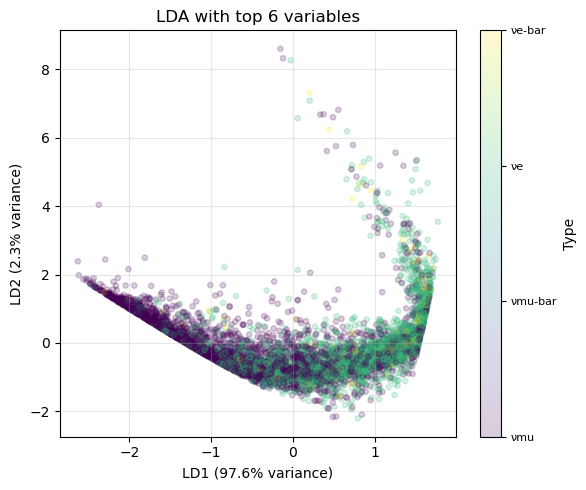

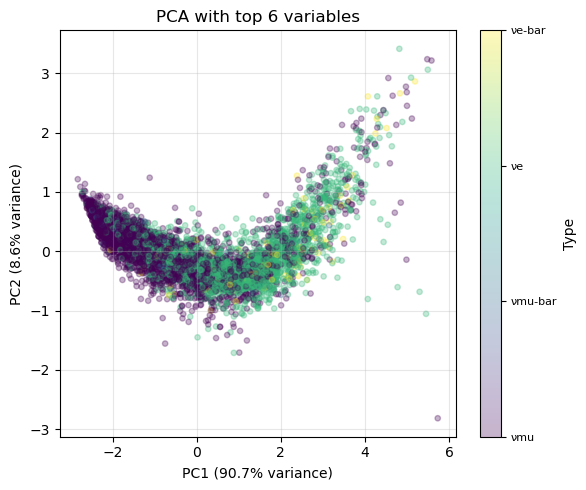

In [4]:
el_E = np.array(tree['el.E'].array())
mu_E = np.array(tree['mu.E'].array())
total_E = el_E + mu_E

data_matrix = np.column_stack([
    np.log(el_E),
    np.log(mu_E),
    np.divide(el_E, total_E, out=np.zeros_like(el_E), where=total_E!=0),
    np.divide(mu_E, total_E, out=np.zeros_like(mu_E), where=total_E!=0),
    np.divide(el_E - mu_E, total_E + 1e-6, out=np.zeros_like(el_E), where=total_E>0),
  # np.array(tree['npi0'].array()), #this isnt given in experimental data so no point in keeping it. however knowing it improves the clustering
    mu_E
])

neutrino_types = np.array(tree["MCEVNT.INNO"].array())

scaler = RobustScaler()
data_scaled = scaler.fit_transform(data_matrix)

lda = LinearDiscriminantAnalysis(n_components=3)
lda_result = lda.fit_transform(data_scaled, neutrino_types)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(lda_result[:, 0], lda_result[:, 1], 
                     c=neutrino_types, cmap='viridis', alpha=0.2, s=15)
cbar = plt.colorbar(scatter, label='Type', ticks=[1, 2, 3, 4])
cbar.ax.set_yticklabels(['νmu', 'νmu-bar', 'νe', 'νe-bar'], fontsize=8)
plt.xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('LDA with top 6 variables')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pca = PCA()
pca_result = pca.fit_transform(data_scaled)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                     c=neutrino_types, cmap='viridis', alpha=0.3, s=15)
cbar = plt.colorbar(scatter, label='Type', ticks=[1, 2, 3, 4])
cbar.ax.set_yticklabels(['νmu', 'νmu-bar', 'νe', 'νe-bar'], fontsize=8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA with top 6 variables')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()